In [38]:
from glob import glob
import nbformat
from nbconvert.preprocessors import ExecutePreprocessor

In [40]:
ep = ExecutePreprocessor()

In [42]:
with open('.\\generate_mesh_2D_cell_RF.ipynb') as generate_mesh:
    nb = nbformat.read(generate_mesh, as_version=4)
    ep.preprocess(nb)

In [44]:
with open('.\\run_ogs.ipynb') as run_ogs:
    nb = nbformat.read(run_ogs, as_version=4)
    ep.preprocess(nb)

In [46]:
import vtuIO
import matplotlib.pyplot as plt

In [48]:
pvdfile = vtuIO.PVDIO("./_out/uplift.pvd", interpolation_backend="scipy", dim=2)
time = pvdfile.timesteps

points = {"pt0": (0, 0, 0), "pt1": (0, -50, 0)}

Text(0, 0.5, 'u')

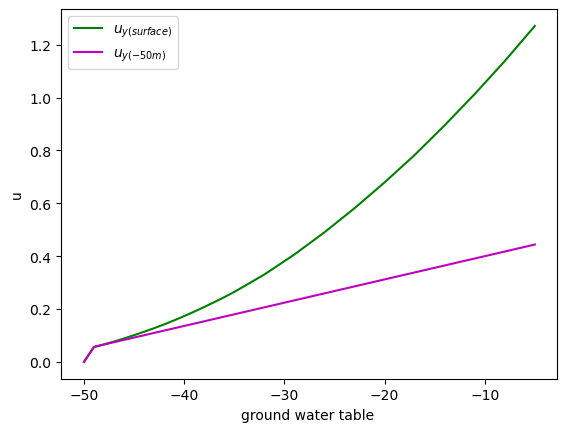

In [50]:
displacement_linear = pvdfile.read_time_series("displacement", points, interpolation_method="linear")

GWT = -50 + time * 1

plt.plot(GWT, displacement_linear["pt0"][:, 1], "g-", label="$u_{y(surface)}$")
plt.plot(GWT, displacement_linear["pt1"][:, 1], "m-", label="$u_{y(-50m)}$")
plt.legend()
plt.xlabel("ground water table ")
plt.ylabel("u")